In [27]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns # Makes the style cleaner
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import lightgbm as lgb
import json
import gc
from pathlib import Path
from scipy import stats


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/jane-street-real-time-market-data-forecasting/responders.csv
/kaggle/input/competitions/jane-street-real-time-market-data-forecasting/sample_submission.csv
/kaggle/input/competitions/jane-street-real-time-market-data-forecasting/features.csv
/kaggle/input/competitions/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=4/part-0.parquet
/kaggle/input/competitions/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=5/part-0.parquet
/kaggle/input/competitions/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=6/part-0.parquet
/kaggle/input/competitions/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=3/part-0.parquet
/kaggle/input/competitions/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=1/part-0.parquet
/kaggle/input/competitions/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=8/part-0.parquet
/kaggle/input/competitions/ja

# Load Data

In [28]:
input_path = "/kaggle/input/competitions/jane-street-real-time-market-data-forecasting"
train_path = input_path + "/train.parquet/**/*.parquet"
data = pl.scan_parquet(train_path)
data

In [29]:
# Read Features CSV Data
features_path = input_path + "/features.csv"
features_data = pl.read_csv(features_path)
features_data

feature,tag_0,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,tag_9,tag_10,tag_11,tag_12,tag_13,tag_14,tag_15,tag_16
str,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool
"""feature_00""",false,false,true,false,false,false,false,false,false,false,false,false,false,false,true,false,true
"""feature_01""",false,false,true,false,false,false,false,false,false,false,false,false,false,true,true,false,true
"""feature_02""",false,false,true,false,false,false,false,false,false,false,false,false,true,false,false,false,true
"""feature_03""",false,false,true,false,false,false,false,false,false,false,false,false,false,true,false,false,true
"""feature_04""",false,false,true,false,false,false,false,false,false,false,false,false,true,true,false,false,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""feature_74""",false,false,false,false,false,false,false,false,true,false,false,false,false,false,true,false,false
"""feature_75""",false,false,false,false,false,false,false,false,true,false,false,false,true,false,false,false,false
"""feature_76""",false,false,false,false,false,false,false,false,true,false,false,false,true,false,false,false,false


In [30]:
print(f"""
Features Columns: {features_data.columns}\n
Features Shape: {features_data.shape}
""")


Features Columns: ['feature', 'tag_0', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8', 'tag_9', 'tag_10', 'tag_11', 'tag_12', 'tag_13', 'tag_14', 'tag_15', 'tag_16']

Features Shape: (79, 18)



In [31]:
# Read Responders CSV Data
responders_path = input_path + "/responders.csv"
responders_data = pl.read_csv(responders_path)
responders_data

responder,tag_0,tag_1,tag_2,tag_3,tag_4
str,bool,bool,bool,bool,bool
"""responder_0""",true,false,true,false,false
"""responder_1""",true,false,false,true,false
"""responder_2""",true,true,false,false,false
"""responder_3""",false,false,true,false,true
"""responder_4""",false,false,false,true,true
"""responder_5""",false,true,false,false,true
"""responder_6""",false,false,true,false,false
"""responder_7""",false,false,false,true,false
"""responder_8""",false,true,false,false,false


In [32]:
print(f"""
Responder Columns: {responders_data.columns}\n
Responder Shape: {responders_data.shape}
""")


Responder Columns: ['responder', 'tag_0', 'tag_1', 'tag_2', 'tag_3', 'tag_4']

Responder Shape: (9, 6)



In [33]:
TRAIN_PATH = "/kaggle/input/competitions/jane-street-real-time-market-data-forecasting/train.parquet"
LAGS_PATH  = "/kaggle/input/competitions/jane-street-real-time-market-data-forecasting/lags.parquet"

# EDA

DATASET SHAPE AND METADATA SCAN
Total columns    : 92
Feature columns  : 79  (feature_00 ... feature_78)
Responder columns: 9  (responder_0, responder_1, responder_2, responder_3, responder_4, responder_5, responder_6, responder_7, responder_8)
Other columns    : date_id, time_id, symbol_id, weight
Target column    : responder_6

shape: (1, 5)
┌────────────┬──────────────┬────────────────┬──────────┬──────────┐
│ total_rows ┆ unique_dates ┆ unique_symbols ┆ date_min ┆ date_max │
│ ---        ┆ ---          ┆ ---            ┆ ---      ┆ ---      │
│ u32        ┆ u32          ┆ u32            ┆ i16      ┆ i16      │
╞════════════╪══════════════╪════════════════╪══════════╪══════════╡
│ 47127338   ┆ 1699         ┆ 39             ┆ 0        ┆ 1698     │
└────────────┴──────────────┴────────────────┴──────────┴──────────┘

Total rows       : 47,127,338
Unique dates     : 1699
Unique symbols   : 39
Date range       : 0 → 1698
Avg symbols/date : 27738.3

MISSING-VALUE AUDIT
Columns with any n

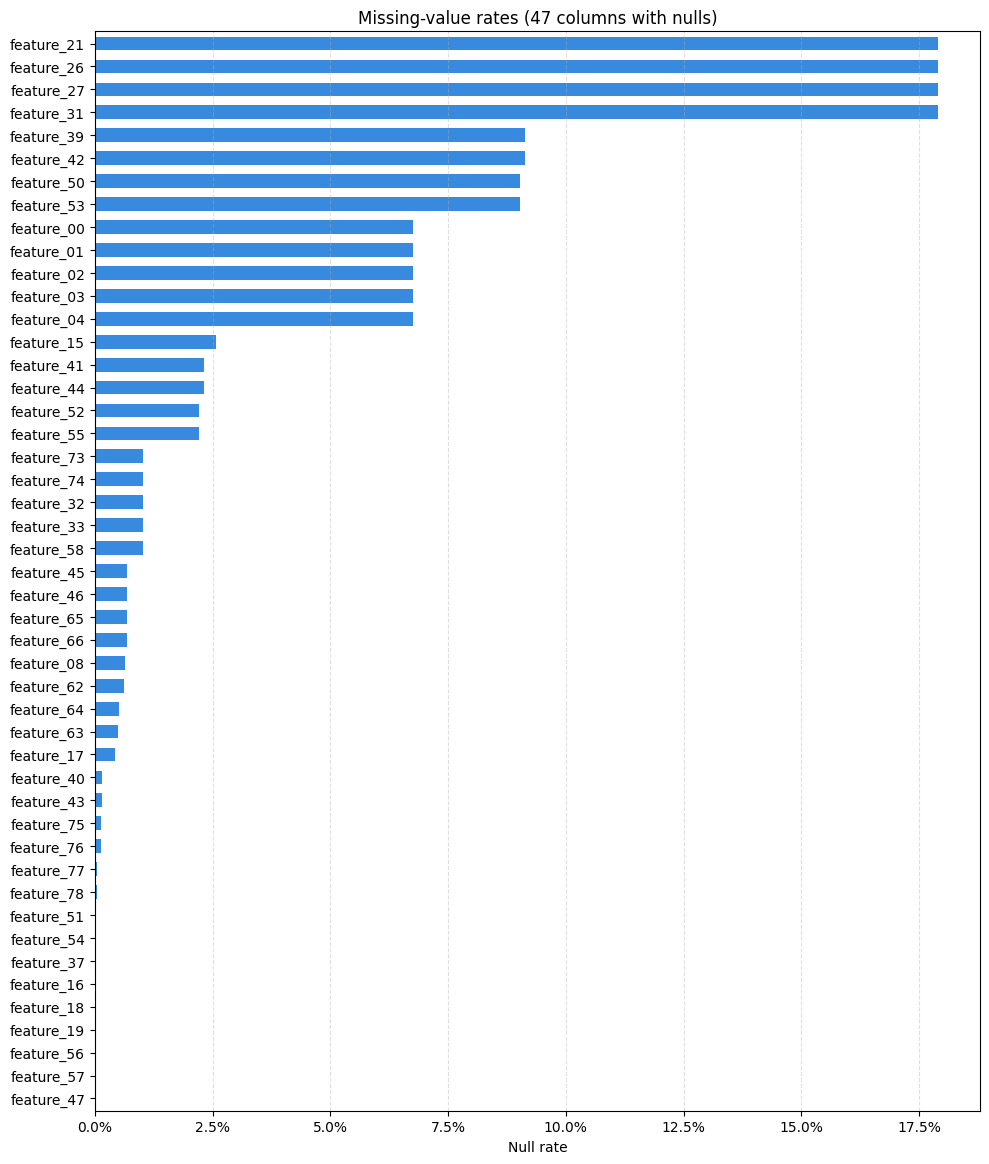

Chart saved → results/eda/01_missing_rates.png

TARGET DISTRIBUTION AND WINSORISATION BOUNDS


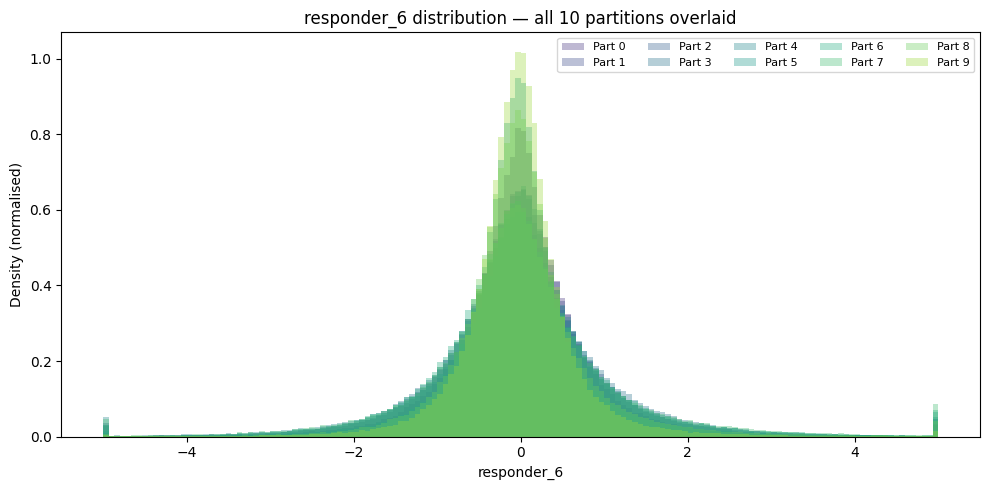


Kurtosis per partition:
  Partition 0: kurtosis = 5.98
  Partition 1: kurtosis = 4.71
  Partition 2: kurtosis = 4.65
  Partition 3: kurtosis = 3.77
  Partition 4: kurtosis = 4.21
  Partition 5: kurtosis = 8.47
  Partition 6: kurtosis = 4.35
  Partition 7: kurtosis = 4.09
  Partition 8: kurtosis = 7.47
  Partition 9: kurtosis = 9.64


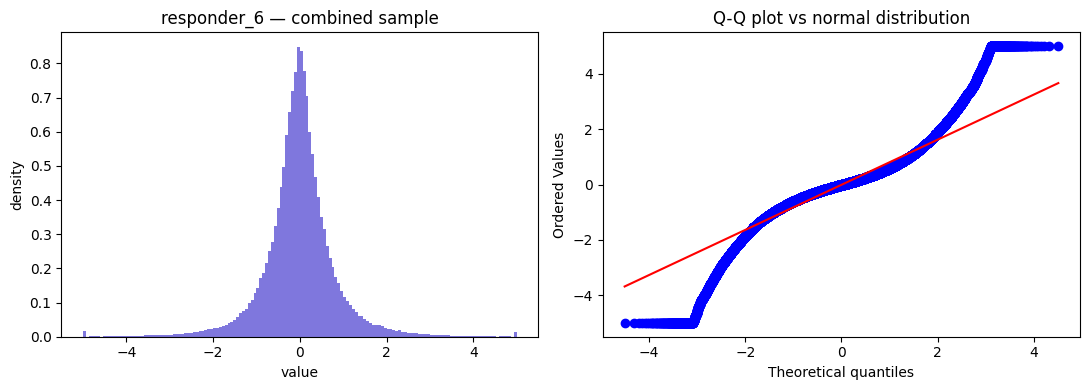


Combined sample statistics:
  Kurtosis      : 5.95  (normal=0, fat tails >> 0)
  Skewness      : 0.0208  (0=symmetric)
  WINSOR_LOWER  : -2.547142
  WINSOR_UPPER  : 2.549128

Charts saved → results/eda/02_target_dist_all_partitions.png
               → results/eda/03_target_qq.png

SYMBOL UNIVERSE STABILITY OVER TIME
Symbols per date - min: 4, max: 39, mean: 29.7


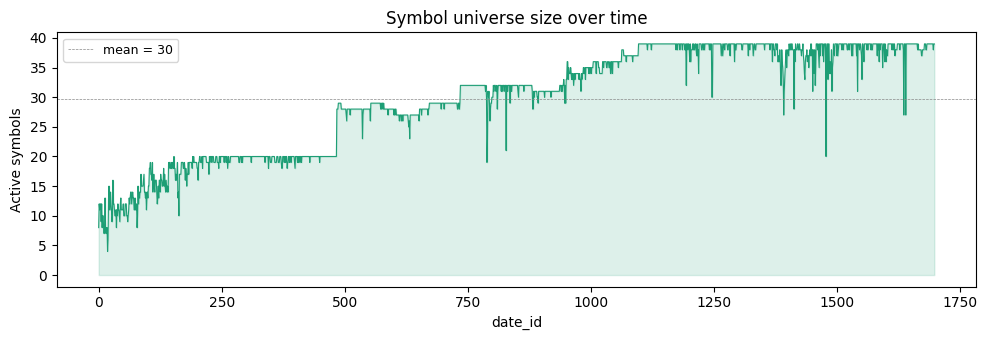

Chart saved → results/eda/04_universe_stability.png

EDA BLOCK COMPLETE
TARGET_COL           = responder_6
N_ROWS               = 47127338
N_DATES              = 1699
N_SYMBOLS            = 39
DATE_MIN             = 0
DATE_MAX             = 1698
WINSOR_LOWER         = -2.547142
WINSOR_UPPER         = 2.549128
TARGET_KURTOSIS      = 5.949999809265137
TARGET_SKEWNESS      = 0.020800000056624413
{'TARGET_COL': 'responder_6', 'N_ROWS': 47127338, 'N_DATES': 1699, 'N_SYMBOLS': 39, 'DATE_MIN': 0, 'DATE_MAX': 1698, 'WINSOR_LOWER': np.float64(-2.547142), 'WINSOR_UPPER': np.float64(2.549128), 'TARGET_KURTOSIS': np.float32(5.95), 'TARGET_SKEWNESS': np.float32(0.0208), 'KURTOSIS_PER_PARTITION': {0: np.float32(5.98), 1: np.float32(4.71), 2: np.float32(4.65), 3: np.float32(3.77), 4: np.float32(4.21), 5: np.float32(8.47), 6: np.float32(4.35), 7: np.float32(4.09), 8: np.float32(7.47), 9: np.float32(9.64)}}


In [34]:
TARGET_COL = "responder_6"
RESULTS_DIR = Path("results/eda")


def perform_eda():
    """
    Covers all 4 tasks related to EDA for the Alpha Factor Discovery Engine:
      -> Dataset shape and metadata scan
      -> Missing-value audit across all partitions
      -> Target distribution and winsorisation bounds
      -> Symbol universe stability over time
    
    All charts are saved to results/eda/ for the GitHub README.
    Returns a dict of key findings to copy into config.py.
    """
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)

    # Lazy scan of full dataset — nothing loaded into RAM yet
    lf = pl.scan_parquet(f"{TRAIN_PATH}/**/part-0.parquet")
    columns = lf.collect_schema().names()

    # ══════════════════════════════════════════════════════════════════════
    # DATASET SHAPE AND METADATA SCAN
    # ══════════════════════════════════════════════════════════════════════
    print("=" * 70)
    print("DATASET SHAPE AND METADATA SCAN")
    print("=" * 70)

    # Column classification
    feature_cols   = [c for c in columns if c.startswith("feature_")]
    responder_cols = [c for c in columns if c.startswith("responder_")]

    print(f"Total columns    : {len(columns)}")
    print(f"Feature columns  : {len(feature_cols)}  (feature_00 ... feature_{len(feature_cols)-1:02d})")
    print(f"Responder columns: {len(responder_cols)}  ({', '.join(responder_cols)})")
    print(f"Other columns    : date_id, time_id, symbol_id, weight")
    print(f"Target column    : {TARGET_COL}")

    # Cardinality - streams through all partitions, returns 1 row
    shape_stats = (
        lf.select([
            pl.len().alias("total_rows"),
            pl.col("date_id").n_unique().alias("unique_dates"),
            pl.col("symbol_id").n_unique().alias("unique_symbols"),
            pl.col("date_id").min().alias("date_min"),
            pl.col("date_id").max().alias("date_max"),
        ])
        .collect()
    )
    print(f"\n{shape_stats}")

    n_rows   = shape_stats["total_rows"][0]
    n_dates  = shape_stats["unique_dates"][0]
    n_symbols = shape_stats["unique_symbols"][0]
    date_min = shape_stats["date_min"][0]
    date_max = shape_stats["date_max"][0]

    print(f"\nTotal rows       : {n_rows:,}")
    print(f"Unique dates     : {n_dates}")
    print(f"Unique symbols   : {n_symbols}")
    print(f"Date range       : {date_min} → {date_max}")
    print(f"Avg symbols/date : {n_rows / n_dates:.1f}")


    # ══════════════════════════════════════════════════════════════════════
    # MISSING-VALUE AUDIT ACROSS ALL PARTITIONS
    # ══════════════════════════════════════════════════════════════════════
    print("\n" + "=" * 70)
    print("MISSING-VALUE AUDIT")
    print("=" * 70)

    missing_rates = (
        lf.select(pl.all().is_null().mean())
        .collect()
        .unpivot()
        .rename({"variable": "column", "value": "null_rate"})
        .sort("null_rate", descending=True)
    )

    cols_with_nulls = missing_rates.filter(pl.col("null_rate") > 0).height
    cols_above_10pct = missing_rates.filter(pl.col("null_rate") > 0.10).height
    print(f"Columns with any nulls : {cols_with_nulls} / {len(columns)}")
    print(f"Columns with >10% null : {cols_above_10pct}")

    # Show top 20
    with pl.Config(tbl_rows=20):
        print(f"\nTop 20 by null rate:\n{missing_rates.head(20)}")

    # Plot - only columns with nulls, sorted so largest bars at top
    df_plot = missing_rates.filter(pl.col("null_rate") > 0).sort("null_rate", descending=False)
    num_cols = df_plot.height
    dynamic_height = max(6, num_cols * 0.25)

    fig, ax = plt.subplots(figsize=(10, dynamic_height))
    ax.barh(df_plot["column"].to_list(), df_plot["null_rate"].to_list(),
            color="#378ADD", height=0.6)
    ax.set_xlabel("Null rate")
    ax.set_title(f"Missing-value rates ({num_cols} columns with nulls)")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.margins(y=0.005)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "01_missing_rates.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Chart saved → {RESULTS_DIR / '01_missing_rates.png'}")


    # ══════════════════════════════════════════════════════════════════════
    # TARGET DISTRIBUTION AND WINSORISATION BOUNDS
    # ══════════════════════════════════════════════════════════════════════
    print("\n" + "=" * 70)
    print("TARGET DISTRIBUTION AND WINSORISATION BOUNDS")
    print("=" * 70)

    # Chart 1: all 10 partitions overlaid
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = plt.cm.viridis(np.linspace(0.15, 0.85, 10))
    kurtosis_per_part = []

    for i in range(10):
        file_path = f"{TRAIN_PATH}/partition_id={i}/part-0.parquet"
        vals = pl.read_parquet(file_path, n_rows=200_000)[TARGET_COL].drop_nulls().to_numpy()
        ax.hist(vals, bins=150, alpha=0.35, color=colors[i], label=f"Part {i}",
                density=True, histtype="stepfilled")
        kurtosis_per_part.append(stats.kurtosis(vals))

    ax.set_xlabel(TARGET_COL)
    ax.set_ylabel("Density (normalised)")
    ax.set_title(f"{TARGET_COL} distribution — all 10 partitions overlaid")
    ax.legend(fontsize=8, ncol=5)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "02_target_dist_all_partitions.png", dpi=150)
    plt.show()

    print("\nKurtosis per partition:")
    for i, k in enumerate(kurtosis_per_part):
        print(f"  Partition {i}: kurtosis = {k:.2f}")

    # Chart 2: Q-Q plot on combined sample (early + mid + late partitions)
    combined = []
    for i in [0, 4, 9]:
        file_path = f"{TRAIN_PATH}/partition_id={i}/part-0.parquet"
        combined.append(
            pl.read_parquet(file_path, n_rows=70_000)[TARGET_COL].drop_nulls().to_numpy()
        )
    target_sample = np.concatenate(combined)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(target_sample, bins=150, color="#7F77DD", edgecolor="none", density=True)
    axes[0].set_title(f"{TARGET_COL} — combined sample")
    axes[0].set_xlabel("value")
    axes[0].set_ylabel("density")

    stats.probplot(target_sample, dist="norm", plot=axes[1])
    axes[1].set_title("Q-Q plot vs normal distribution")

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "03_target_qq.png", dpi=150)
    plt.show()

    # Compute final statistics
    kurt = stats.kurtosis(target_sample)
    skew = stats.skew(target_sample)
    p01, p99 = np.percentile(target_sample, [1, 99])

    print(f"\nCombined sample statistics:")
    print(f"  Kurtosis      : {kurt:.2f}  (normal=0, fat tails >> 0)")
    print(f"  Skewness      : {skew:.4f}  (0=symmetric)")
    print(f"  WINSOR_LOWER  : {p01:.6f}")
    print(f"  WINSOR_UPPER  : {p99:.6f}")
    print(f"\nCharts saved → {RESULTS_DIR / '02_target_dist_all_partitions.png'}")
    print(f"               → {RESULTS_DIR / '03_target_qq.png'}")


    # ══════════════════════════════════════════════════════════════════════
    # SYMBOL UNIVERSE STABILITY OVER TIME
    # ══════════════════════════════════════════════════════════════════════
    print("\n" + "=" * 70)
    print("SYMBOL UNIVERSE STABILITY OVER TIME")
    print("=" * 70)

    symbols_per_date = (
        lf.group_by("date_id")
        .agg(pl.col("symbol_id").n_unique().alias("n_symbols"))
        .sort("date_id")
        .collect()
    )

    min_sym = symbols_per_date["n_symbols"].min()
    max_sym = symbols_per_date["n_symbols"].max()
    mean_sym = symbols_per_date["n_symbols"].mean()

    print(f"Symbols per date - min: {min_sym}, max: {max_sym}, mean: {mean_sym:.1f}")

    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.plot(symbols_per_date["date_id"].to_list(),
            symbols_per_date["n_symbols"].to_list(),
            linewidth=0.8, color="#1D9E75")
    ax.fill_between(symbols_per_date["date_id"].to_list(),
                     symbols_per_date["n_symbols"].to_list(),
                     alpha=0.15, color="#1D9E75")
    ax.set_xlabel("date_id")
    ax.set_ylabel("Active symbols")
    ax.set_title("Symbol universe size over time")
    ax.axhline(mean_sym, color="#888", linewidth=0.5, linestyle="--", label=f"mean = {mean_sym:.0f}")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "04_universe_stability.png", dpi=150)
    plt.show()
    print(f"Chart saved → {RESULTS_DIR / '04_universe_stability.png'}")


    # ══════════════════════════════════════════════════════════════════════
    # SUMMARY - findings for config.py
    # ══════════════════════════════════════════════════════════════════════
    findings = {
        "TARGET_COL":     TARGET_COL,
        "N_ROWS":         n_rows,
        "N_DATES":        n_dates,
        "N_SYMBOLS":      n_symbols,
        "DATE_MIN":       date_min,
        "DATE_MAX":       date_max,
        "WINSOR_LOWER":   round(p01, 6),
        "WINSOR_UPPER":   round(p99, 6),
        "TARGET_KURTOSIS": round(kurt, 2),
        "TARGET_SKEWNESS": round(skew, 4),
        "KURTOSIS_PER_PARTITION": {i: round(k, 2) for i, k in enumerate(kurtosis_per_part)},
    }

    print("\n" + "=" * 70)
    print("EDA BLOCK COMPLETE")
    print("=" * 70)
    for key, val in findings.items():
        if key != "KURTOSIS_PER_PARTITION":
            print(f"{key:20s} = {val}")

    return findings


# ── Run ───────────────────────────────────────────────────────────────────────
findings = perform_eda()
print(findings)

# Feature Engineering

In [35]:
#Config (from EDA findings)
TRAIN_PATH   = "/kaggle/input/competitions/jane-street-real-time-market-data-forecasting/train.parquet"
LAGS_PATH    = "/kaggle/input/competitions/jane-street-real-time-market-data-forecasting/lags.parquet"
TARGET_COL   = "responder_6"
WINSOR_LOWER = -2.547142
WINSOR_UPPER = 2.549128
JOIN_KEYS    = ["date_id", "time_id", "symbol_id"]
META_COLS    = ["date_id", "time_id", "symbol_id", "weight"]

ROLLING_WINDOWS = [5, 21]          # weekly + monthly timescales
N_TOP_FEATURES  = 10               # for rolling stats
N_TOP_INTERACT  = 6                # for interaction pairs
IMPORTANCE_THRESHOLD = 0.5         # drop features below this %

RESULTS_DIR = Path("results/features")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Feature Selection

In [36]:
print("=" * 70)
print("FEATURE SELECTION (all 10 partitions, 200k each, float32)")
print("=" * 70)
 
SAMPLE_PER_PARTITION = 200_000
 
frames = []
for pid in range(10):
    path = f"{TRAIN_PATH}/partition_id={pid}/part-0.parquet"
    df_part = pl.read_parquet(path, n_rows=SAMPLE_PER_PARTITION)
    frames.append(df_part)
    print(f"  Partition {pid}: {df_part.shape[0]:,} rows")
 
df = pl.concat(frames)
del frames; gc.collect()
 
# Float32 compression
f64 = [c for c in df.columns if df.schema[c] == pl.Float64]
if f64:
    df = df.cast({c: pl.Float32 for c in f64})
 
print(f"\nCombined : {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Memory   : ~{df.estimated_size() / 1e9:.2f} GB")
 
 
# Merge lags + apply B1-B4 transformations eagerly 
 
# merge lags
df_lags = pl.read_parquet(LAGS_PATH)
f64_l = [c for c in df_lags.columns if df_lags.schema[c] == pl.Float64]
if f64_l:
    df_lags = df_lags.cast({c: pl.Float32 for c in f64_l})
 
df = df.join(df_lags, on=JOIN_KEYS, how="left")
del df_lags; gc.collect()
 
feature_cols = sorted([c for c in df.columns if c.startswith("feature_")])
lag_cols     = sorted([c for c in df.columns if "_lag_" in c])
print(f"After merge: {df.shape[1]} cols, ~{df.estimated_size() / 1e9:.2f} GB")
 
# rolling stats
df = df.sort(["symbol_id", "date_id", "time_id"])

feature_cols = sorted([c for c in df.columns if c.startswith("feature_")])
correlations = {}
all_input_cols = feature_cols + lag_cols
 
for col in all_input_cols:
    valid = df.select([col, TARGET_COL]).drop_nulls()
    if valid.height > 1000:
        r, _ = stats.pearsonr(valid[col].to_numpy(), valid[TARGET_COL].to_numpy())
        correlations[col] = abs(r)
        
sorted_corrs = sorted(correlations.items(), key=lambda x: x[1], reverse=True)
TOP_FEATURES = [name for name, _ in sorted_corrs[:N_TOP_FEATURES]]

rolling_col_names = []
 
for feat in TOP_FEATURES:
    if feat not in df.columns:
        continue
    for w in ROLLING_WINDOWS:
        rmean = f"{feat}_rmean_{w}"
        rstd  = f"{feat}_rstd_{w}"
        zsc   = f"{feat}_zscore_{w}"
        df = df.with_columns([
            pl.col(feat).rolling_mean(window_size=w, min_samples=1)
              .over("symbol_id").alias(rmean),
            pl.col(feat).rolling_std(window_size=w, min_samples=2)
              .over("symbol_id").alias(rstd),
        ])
        df = df.with_columns(
            ((pl.col(feat) - pl.col(rmean)) / (pl.col(rstd) + 1e-8)).alias(zsc)
        )
        rolling_col_names.extend([rmean, rstd, zsc])
 
print(f"Rolling features: {len(rolling_col_names)}")
 
# cross-sectional ranks
cols_to_rank = [c for c in TOP_FEATURES + lag_cols if c in df.columns]
rank_col_names = []
 
for col in cols_to_rank:
    rname = f"rank_{col}"
    df = df.with_columns(
        (pl.col(col).rank().over("date_id")
         / pl.col(col).count().over("date_id"))
        .cast(pl.Float32)
        .alias(rname)
    )
    rank_col_names.append(rname)
 
print(f"Rank features: {len(rank_col_names)}")
 
# interactions
top_ix = [f for f in TOP_FEATURES[:N_TOP_INTERACT] if f in df.columns]
interaction_col_names = []
 
for i in range(len(top_ix)):
    for j in range(i + 1, len(top_ix)):
        a_s = top_ix[i].replace("feature_", "").replace("responder_", "resp")
        b_s = top_ix[j].replace("feature_", "").replace("responder_", "resp")
        prod = f"ix_{a_s}_x_{b_s}"
        diff = f"ix_{a_s}_diff_{b_s}"
        df = df.with_columns([
            (pl.col(top_ix[i]) * pl.col(top_ix[j])).alias(prod),
            (pl.col(top_ix[i]) - pl.col(top_ix[j])).abs().alias(diff),
        ])
        interaction_col_names.extend([prod, diff])
 
print(f"Interaction features: {len(interaction_col_names)}")
 
ALL_ENGINEERED = (
    feature_cols
    + lag_cols
    + rolling_col_names
    + rank_col_names
    + interaction_col_names
)
 
print(f"\nTotal engineered: {len(ALL_ENGINEERED)}")
print(f"Memory: ~{df.estimated_size() / 1e9:.2f} GB")
gc.collect()

FEATURE SELECTION (all 10 partitions, 200k each, float32)
  Partition 0: 200,000 rows
  Partition 1: 200,000 rows
  Partition 2: 200,000 rows
  Partition 3: 200,000 rows
  Partition 4: 200,000 rows
  Partition 5: 200,000 rows
  Partition 6: 200,000 rows
  Partition 7: 200,000 rows
  Partition 8: 200,000 rows
  Partition 9: 200,000 rows

Combined : 2,000,000 rows × 92 cols
Memory   : ~0.71 GB
After merge: 101 cols, ~0.79 GB
Rolling features: 60
Rank features: 19
Interaction features: 30

Total engineered: 197
Memory: ~1.69 GB


0

# Feature Importance

LIGHTGBM FEATURE IMPORTANCE
Training sample: 250,000 rows × 197 features
Training LightGBM (200 rounds)...
[50]	training's rmse: 0.857943
[100]	training's rmse: 0.841521
[150]	training's rmse: 0.827602
[200]	training's rmse: 0.814886

Top 30 features:
shape: (30, 3)
┌─────────────────────┬─────────────┬────────────────┐
│ feature             ┆ importance  ┆ importance_pct │
│ ---                 ┆ ---         ┆ ---            │
│ str                 ┆ f64         ┆ f64            │
╞═════════════════════╪═════════════╪════════════════╡
│ rank_feature_60     ┆ 4345.266081 ┆ 1.598621       │
│ feature_06          ┆ 3595.336089 ┆ 1.322722       │
│ feature_01          ┆ 3564.743305 ┆ 1.311467       │
│ feature_08          ┆ 3427.349211 ┆ 1.26092        │
│ feature_59_rstd_21  ┆ 3310.690801 ┆ 1.218001       │
│ feature_30          ┆ 3215.112267 ┆ 1.182838       │
│ feature_22          ┆ 3214.089292 ┆ 1.182461       │
│ feature_21          ┆ 3081.484444 ┆ 1.133676       │
│ feature_47      

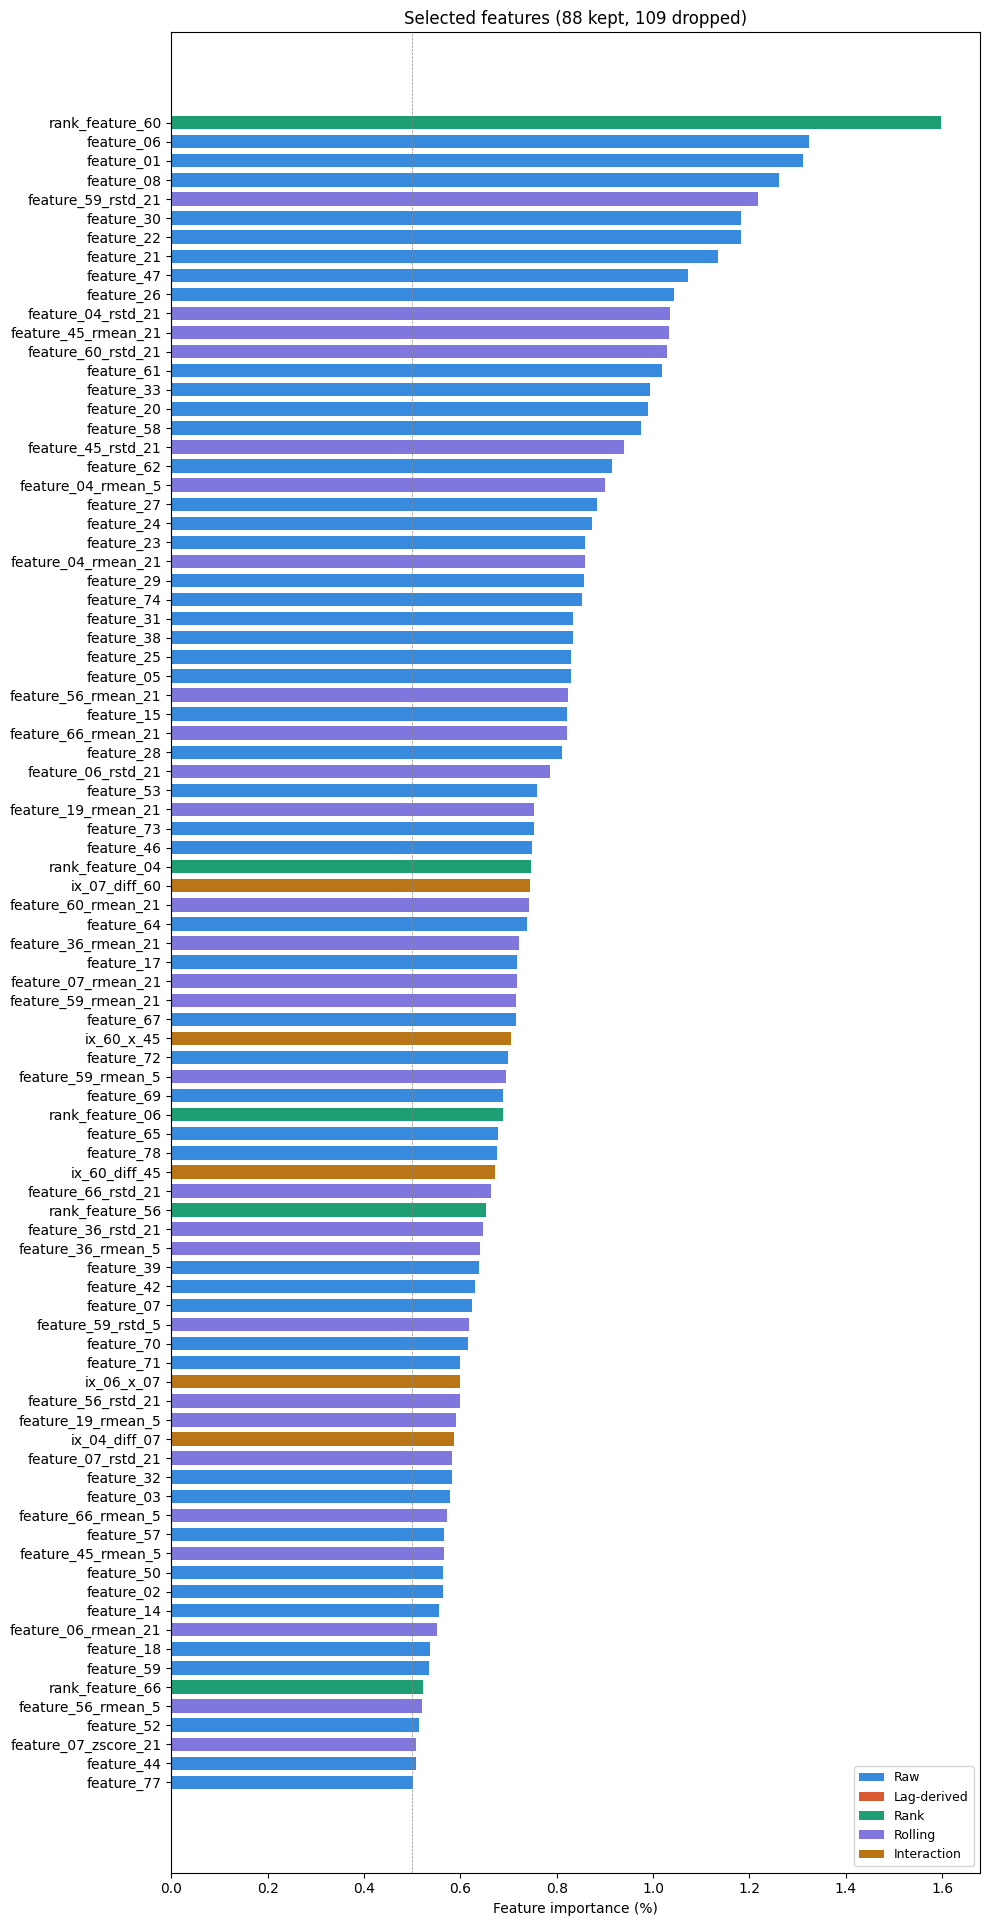


Feature list saved → results/features/selected_features.json


6729

In [37]:
# LightGBM feature importance and selection
 
print("=" * 70)
print("LIGHTGBM FEATURE IMPORTANCE")
print("=" * 70)
 
# Sample 250k rows for training
sample_size = min(250_000, df.height)
idx = np.random.RandomState(42).choice(df.height, size=sample_size, replace=False)
df_sample = df[idx.tolist()]
 
valid_features = [c for c in ALL_ENGINEERED if c in df_sample.columns]
X = df_sample.select(valid_features).to_pandas().astype(np.float32)
y = df_sample[TARGET_COL].to_numpy().astype(np.float32)
y = np.clip(y, WINSOR_LOWER, WINSOR_UPPER)
 
mask = ~np.isnan(y)
X, y = X[mask], y[mask]
print(f"Training sample: {X.shape[0]:,} rows × {X.shape[1]} features")
 
del df_sample; gc.collect()
 
lgb_data = lgb.Dataset(X, label=y, free_raw_data=True)
 
params = {
    "objective":        "regression",
    "metric":           "rmse",
    "verbosity":        -1,
    "num_leaves":       63,
    "learning_rate":    0.05,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq":     1,
    "n_jobs":           -1,
}
 
print("Training LightGBM (200 rounds)...")
model = lgb.train(
    params, lgb_data,
    num_boost_round=200,
    valid_sets=[lgb_data],
    callbacks=[lgb.log_evaluation(50)],
)
 
# Importance
importance = model.feature_importance(importance_type="gain")
imp_lf = (
    pl.DataFrame({"feature": valid_features, "importance": importance})
    .with_columns(
        (pl.col("importance") / pl.col("importance").sum() * 100).alias("importance_pct")
    )
    .sort("importance_pct", descending=True)
)
 
with pl.Config(tbl_rows=30):
    print(f"\nTop 30 features:")
    print(imp_lf.head(30))
 
selected_lf = imp_lf.filter(pl.col("importance_pct") >= IMPORTANCE_THRESHOLD)
dropped_lf  = imp_lf.filter(pl.col("importance_pct") < IMPORTANCE_THRESHOLD)
SELECTED_FEATURES = selected_lf["feature"].to_list()
 
print(f"\n{'─' * 50}")
print(f"Selected : {len(SELECTED_FEATURES)} features (≥{IMPORTANCE_THRESHOLD}%)")
print(f"Dropped  : {dropped_lf.height} features (<{IMPORTANCE_THRESHOLD}%)")
print(f"Top 5    : {SELECTED_FEATURES[:5]}")
 
# Plot
fig, ax = plt.subplots(figsize=(10, max(6, len(SELECTED_FEATURES) * 0.22)))
plot_lf = selected_lf.sort("importance_pct", descending=False)
 
color_map = []
for name in plot_lf["feature"].to_list():
    if "_lag_" in name or "rank_resp" in name:
        color_map.append("#D85A30")
    elif name.startswith("rank_"):
        color_map.append("#1D9E75")
    elif any(s in name for s in ["rmean", "rstd", "zscore"]):
        color_map.append("#7F77DD")
    elif name.startswith("ix_"):
        color_map.append("#BA7517")
    else:
        color_map.append("#378ADD")
 
ax.barh(plot_lf["feature"].to_list(), plot_lf["importance_pct"].to_list(),
        color=color_map, height=0.7)
ax.axvline(IMPORTANCE_THRESHOLD, color="#888", linewidth=0.5, linestyle="--")
ax.set_xlabel("Feature importance (%)")
ax.set_title(f"Selected features ({len(SELECTED_FEATURES)} kept, {dropped_lf.height} dropped)")
 
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#378ADD", label="Raw"),
    Patch(facecolor="#D85A30", label="Lag-derived"),
    Patch(facecolor="#1D9E75", label="Rank"),
    Patch(facecolor="#7F77DD", label="Rolling"),
    Patch(facecolor="#BA7517", label="Interaction"),
], loc="lower right", fontsize=9)
 
plt.tight_layout()
plt.savefig(RESULTS_DIR / "02_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
 
with open(RESULTS_DIR / "selected_features.json", "w") as f:
    json.dump(SELECTED_FEATURES, f, indent=2)
print(f"\nFeature list saved → {RESULTS_DIR / 'selected_features.json'}")
 
# Update global column name lists
rolling_col_names     = rolling_col_names
rank_col_names        = rank_col_names
interaction_col_names = interaction_col_names
 
del X, y, lgb_data, model, importance, df
gc.collect()

In [38]:
# FactorLibrary class (with float32 compression)
 
print("=" * 70)
print("FACTORLIBRARY CLASS")
print("=" * 70)
 
 
class FactorLibrary:
    """
    Deterministic feature engineering pipeline for the Alpha Factor Engine.
    Processes data eagerly with float32 compression.
 
    Usage:
        fl = FactorLibrary.from_json("results/features/factor_library_config.json")
        df = fl.transform(partitions=[0,1,2,3,4,5,6,7,8,9])
    """
 
    def __init__(
        self,
        top_features:      list,
        selected_features: list,
        rolling_windows:   list = None,
        n_top_interact:    int  = 6,
        target_col:        str  = "responder_6",
        winsor_lower:      float = -2.547142,
        winsor_upper:      float = 2.549128,
        train_path:        str  = TRAIN_PATH,
        lags_path:         str  = LAGS_PATH,
    ):
        self.top_features      = top_features
        self.selected_features = selected_features
        self.rolling_windows   = rolling_windows or [5, 21]
        self.n_top_interact    = n_top_interact
        self.target_col        = target_col
        self.winsor_lower      = winsor_lower
        self.winsor_upper      = winsor_upper
        self.train_path        = train_path
        self.lags_path         = lags_path
        self.join_keys         = ["date_id", "time_id", "symbol_id"]
        self.meta_cols         = ["date_id", "time_id", "symbol_id", "weight"]
 
    @classmethod
    def from_json(cls, config_path: str):
        with open(config_path) as f:
            cfg = json.load(f)
        return cls(
            top_features=cfg["top_features"],
            selected_features=cfg["selected_features"],
            rolling_windows=cfg.get("rolling_windows", [5, 21]),
            n_top_interact=cfg.get("n_top_interact", 6),
            target_col=cfg.get("target_col", "responder_6"),
            winsor_lower=cfg.get("winsor_lower", -2.547142),
            winsor_upper=cfg.get("winsor_upper", 2.549128),
        )
 
    def _compress_float64(self, df: pl.DataFrame) -> pl.DataFrame:
        """Downcast all Float64 columns to Float32."""
        f64 = [c for c in df.columns if df.schema[c] == pl.Float64]
        if f64:
            df = df.cast({c: pl.Float32 for c in f64})
        return df
 
    def transform(self, partitions: list = None) -> pl.DataFrame:
        """
        Load partitions, merge lags, engineer features, select, compress.
        Returns a float32 DataFrame with only selected features + meta + target.
        """
        if partitions is None:
            partitions = list(range(10))
 
        # Load + compress
        frames = []
        for pid in partitions:
            path = f"{self.train_path}/partition_id={pid}/part-0.parquet"
            frames.append(pl.read_parquet(path))
        df = self._compress_float64(pl.concat(frames))
        del frames; gc.collect()
 
        # merge lags
        df_lags = self._compress_float64(pl.read_parquet(self.lags_path))
        df = df.join(df_lags, on=self.join_keys, how="left")
        del df_lags; gc.collect()
 
        feature_cols = sorted([c for c in df.columns if c.startswith("feature_")])
        lag_cols = sorted([c for c in df.columns if "_lag_" in c])
 
        # rolling stats
        df = df.sort(["symbol_id", "date_id", "time_id"])
        for feat in self.top_features:
            if feat not in df.columns:
                continue
            for w in self.rolling_windows:
                rmean = f"{feat}_rmean_{w}"
                rstd  = f"{feat}_rstd_{w}"
                zsc   = f"{feat}_zscore_{w}"
                df = df.with_columns([
                    pl.col(feat).rolling_mean(window_size=w, min_samples=1)
                      .over("symbol_id").cast(pl.Float32).alias(rmean),
                    pl.col(feat).rolling_std(window_size=w, min_samples=2)
                      .over("symbol_id").cast(pl.Float32).alias(rstd),
                ])
                df = df.with_columns(
                    ((pl.col(feat) - pl.col(rmean)) / (pl.col(rstd) + 1e-8))
                    .cast(pl.Float32).alias(zsc)
                )
 
        # cross-sectional ranks
        cols_to_rank = [c for c in self.top_features + lag_cols if c in df.columns]
        for col in cols_to_rank:
            df = df.with_columns(
                (pl.col(col).rank().over("date_id")
                 / pl.col(col).count().over("date_id"))
                .cast(pl.Float32).alias(f"rank_{col}")
            )
 
        # interactions
        top_ix = [f for f in self.top_features[:self.n_top_interact] if f in df.columns]
        for i in range(len(top_ix)):
            for j in range(i + 1, len(top_ix)):
                a_s = top_ix[i].replace("feature_", "").replace("responder_", "resp")
                b_s = top_ix[j].replace("feature_", "").replace("responder_", "resp")
                df = df.with_columns([
                    (pl.col(top_ix[i]) * pl.col(top_ix[j]))
                      .cast(pl.Float32).alias(f"ix_{a_s}_x_{b_s}"),
                    (pl.col(top_ix[i]) - pl.col(top_ix[j])).abs()
                      .cast(pl.Float32).alias(f"ix_{a_s}_diff_{b_s}"),
                ])
 
        # Select only needed columns + winsorise target
        keep = [c for c in self.selected_features if c in df.columns]
        final = self.meta_cols + keep + [self.target_col]
        final = [c for c in final if c in df.columns]
 
        df = df.select(final).with_columns(
            pl.col(self.target_col).clip(self.winsor_lower, self.winsor_upper)
        )
        gc.collect()
        return df
 
    def get_feature_names(self) -> list:
        return self.selected_features.copy()
 
 
# Save config
fl_config = {
    "top_features":      TOP_FEATURES,
    "selected_features": SELECTED_FEATURES,
    "rolling_windows":   ROLLING_WINDOWS,
    "n_top_interact":    N_TOP_INTERACT,
    "target_col":        TARGET_COL,
    "winsor_lower":      WINSOR_LOWER,
    "winsor_upper":      WINSOR_UPPER,
}
with open(RESULTS_DIR / "factor_library_config.json", "w") as f:
    json.dump(fl_config, f, indent=2)
 
print("FactorLibrary class defined ✓")
print(f"Config saved → {RESULTS_DIR / 'factor_library_config.json'}")

FACTORLIBRARY CLASS
FactorLibrary class defined ✓
Config saved → results/features/factor_library_config.json


In [39]:
#summary  
print("=" * 70)
print("Feature Engineering COMPLETE")
print("=" * 70)
 
raw_ct  = sum(1 for f in SELECTED_FEATURES if f.startswith("feature_") and "rank" not in f and "rmean" not in f and "rstd" not in f and "zscore" not in f)
lag_ct  = sum(1 for f in SELECTED_FEATURES if "_lag_" in f and "rank" not in f)
roll_ct = sum(1 for f in SELECTED_FEATURES if any(s in f for s in ["rmean", "rstd", "zscore"]))
rank_ct = sum(1 for f in SELECTED_FEATURES if f.startswith("rank_"))
ix_ct   = sum(1 for f in SELECTED_FEATURES if f.startswith("ix_"))
 
print(f"Selected: {len(SELECTED_FEATURES)} features")
print(f"  Raw: {raw_ct} | Lag: {lag_ct} | Rolling: {roll_ct} | Rank: {rank_ct} | Interaction: {ix_ct}")

Feature Engineering COMPLETE
Selected: 88 features
  Raw: 50 | Lag: 0 | Rolling: 28 | Rank: 5 | Interaction: 5


# Target Variable Construction

In [40]:
# ═══════════════════════════════════════════════════════════════════════════════
#  TARGET VARIABLE CONSTRUCTION
# ═══════════════════════════════════════════════════════════════════════════════

# Load data through FactorLibrary

print("=" * 70)
print("TARGET VARIABLE CONSTRUCTION")
print("=" * 70)

# Load 3 partitions for development (before committing to 
# the full 19M-row of all the 10 partition data) — full data loads in later sections of code
fl = FactorLibrary.from_json("results/features/factor_library_config.json")

# Load partitions 2, 5, 8 partition data - as they are evenly spaced across 
# the timeline — early-ish, middle and late, out of all the total 10 partitions
print("Loading partitions 2, 5, 8 through FactorLibrary...")
df = fl.transform(partitions=[2, 5, 8])
print(f"Shape  : {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Memory : ~{df.estimated_size() / 1e9:.2f} GB")

# Verify winsorisation applied
print(f"\n{TARGET_COL} after winsorisation:")
print(f"  min : {df[TARGET_COL].min():.4f}  (bound: {WINSOR_LOWER})")
print(f"  max : {df[TARGET_COL].max():.4f}  (bound: {WINSOR_UPPER})")
print("Data loaded\n")

TARGET VARIABLE CONSTRUCTION
Loading partitions 2, 5, 8 through FactorLibrary...
Shape  : 14,525,097 rows × 93 cols
Memory : ~5.39 GB

responder_6 after winsorisation:
  min : -2.5471  (bound: -2.547142)
  max : 2.5491  (bound: 2.549128)
Data loaded



CROSS-SECTIONAL RANK - TARGET
rank_target statistics:
shape: (1, 4)
┌──────────┬─────────┬──────────┬──────────┐
│ min      ┆ max     ┆ mean     ┆ std      │
│ ---      ┆ ---     ┆ ---      ┆ ---      │
│ f32      ┆ f32     ┆ f32      ┆ f32      │
╞══════════╪═════════╪══════════╪══════════╡
│ 0.000185 ┆ 0.99885 ┆ 0.500018 ┆ 0.288673 │
└──────────┴─────────┴──────────┴──────────┘

Spot check — date_id 935 (all symbols ranked):
shape: (30_008, 4)
┌─────────┬───────────┬─────────────┬─────────────┐
│ date_id ┆ symbol_id ┆ responder_6 ┆ rank_target │
│ ---     ┆ ---       ┆ ---         ┆ ---         │
│ i16     ┆ i8        ┆ f32         ┆ f32         │
╞═════════╪═══════════╪═════════════╪═════════════╡
│ 935     ┆ 0         ┆ -2.547142   ┆ 0.001566    │
│ 935     ┆ 0         ┆ -2.547142   ┆ 0.001566    │
│ 935     ┆ 0         ┆ -2.547142   ┆ 0.001566    │
│ 935     ┆ 0         ┆ -2.547142   ┆ 0.001566    │
│ 935     ┆ 0         ┆ -2.547142   ┆ 0.001566    │
│ …       ┆ …         ┆ …     

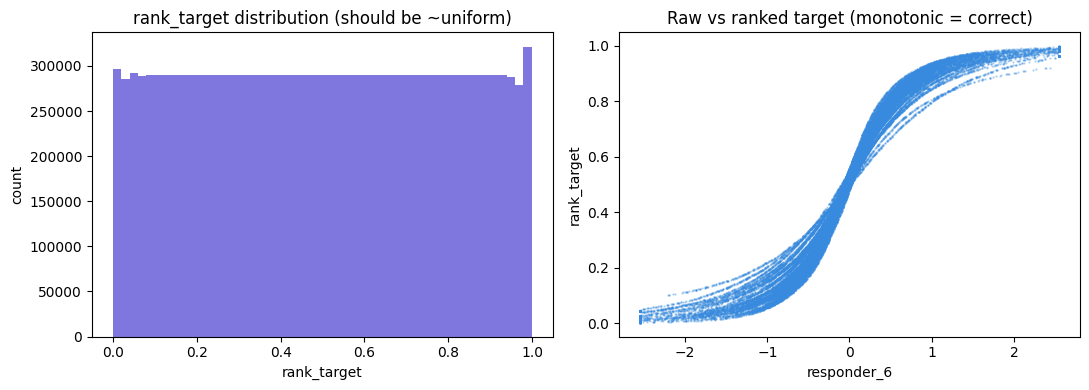

In [41]:
# Cross-sectional rank - target

print("=" * 70)
print("CROSS-SECTIONAL RANK - TARGET")
print("=" * 70)

# Rank responder_6 across all symbols within each date
# Normalise to [0, 1] so the target represents relative performance
df = df.with_columns(
    (pl.col(TARGET_COL).rank().over("date_id")
     / pl.col(TARGET_COL).count().over("date_id"))
    .cast(pl.Float32)
    .alias("rank_target")
)

# Verify the rank target
rank_stats = df.select([
    pl.col("rank_target").min().alias("min"),
    pl.col("rank_target").max().alias("max"),
    pl.col("rank_target").mean().alias("mean"),
    pl.col("rank_target").std().alias("std"),
])
print(f"rank_target statistics:")
print(rank_stats)

# Spot check: pick one date and show all symbols ranked
sample_date_id = df["date_id"].unique().sort().to_list()[len(df["date_id"].unique()) // 2]
spot_check = (
    df.filter(pl.col("date_id") == sample_date_id)
    .select(["date_id", "symbol_id", TARGET_COL, "rank_target"])
    .sort("rank_target")
)
print(f"\nSpot check — date_id {sample_date_id} (all symbols ranked):")
with pl.Config(tbl_rows=10):
    print(spot_check)

# Plot rank_target distribution (should be approximately uniform)
RESULTS_C = Path("results/target")
RESULTS_C.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df["rank_target"].to_numpy(), bins=50, color="#7F77DD", edgecolor="none")
axes[0].set_title("rank_target distribution (should be ~uniform)")
axes[0].set_xlabel("rank_target")
axes[0].set_ylabel("count")


# Correlation: raw target vs rank target
axes[1].scatter(
    df[TARGET_COL].to_numpy()[:50_000],
    df["rank_target"].to_numpy()[:50_000],
    s=0.5, alpha=0.3, color="#378ADD"
)
axes[1].set_xlabel(TARGET_COL)
axes[1].set_ylabel("rank_target")
axes[1].set_title("Raw vs ranked target (monotonic = correct)")

plt.tight_layout()
plt.savefig(RESULTS_C / "01_rank_target.png", dpi=150)
plt.show()

SAMPLE WEIGHT HANDLING
Weight statistics:
shape: (1, 7)
┌──────────┬───────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
│ min      ┆ max       ┆ mean     ┆ median   ┆ std      ┆ pct_zero ┆ pct_null │
│ ---      ┆ ---       ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ f32      ┆ f32       ┆ f32      ┆ f32      ┆ f32      ┆ f64      ┆ f64      │
╞══════════╪═══════════╪══════════╪══════════╪══════════╪══════════╪══════════╡
│ 0.282808 ┆ 10.240419 ┆ 2.264954 ┆ 1.975386 ┆ 1.246771 ┆ 0.0      ┆ 0.0      │
└──────────┴───────────┴──────────┴──────────┴──────────┴──────────┴──────────┘


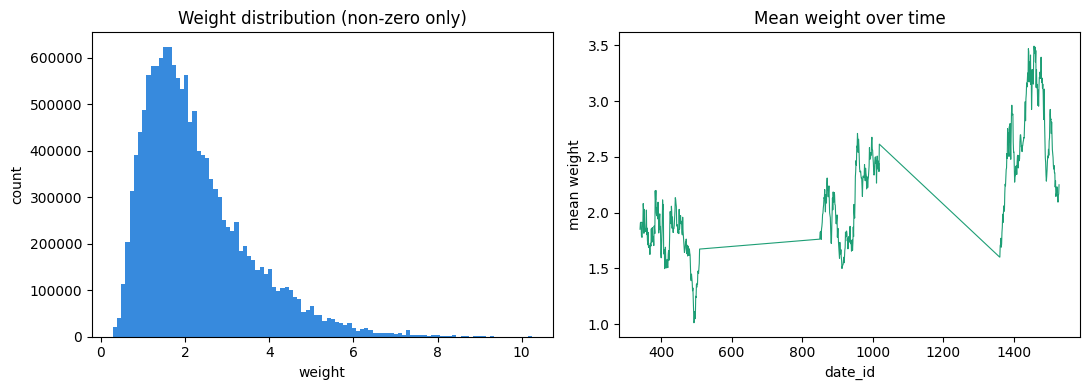


Zero-weight rows: 0.00%
Final rows: 14,525,097


In [42]:
# Weight handling

print("=" * 70)
print("SAMPLE WEIGHT HANDLING")
print("=" * 70)

weight_stats = df.select([
    pl.col("weight").min().alias("min"),
    pl.col("weight").max().alias("max"),
    pl.col("weight").mean().alias("mean"),
    pl.col("weight").median().alias("median"),
    pl.col("weight").std().alias("std"),
    (pl.col("weight") == 0).mean().alias("pct_zero"),
    pl.col("weight").is_null().mean().alias("pct_null"),
])
print("Weight statistics:")
print(weight_stats)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

weights = df["weight"].drop_nulls().to_numpy()
axes[0].hist(weights[weights > 0], bins=100, color="#378ADD", edgecolor="none")
axes[0].set_title("Weight distribution (non-zero only)")
axes[0].set_xlabel("weight")
axes[0].set_ylabel("count")

weight_by_date = (
    df.group_by("date_id")
    .agg(pl.col("weight").mean().alias("mean_weight"))
    .sort("date_id")
)
axes[1].plot(weight_by_date["date_id"].to_list(),
             weight_by_date["mean_weight"].to_list(),
             linewidth=0.8, color="#1D9E75")
axes[1].set_title("Mean weight over time")
axes[1].set_xlabel("date_id")
axes[1].set_ylabel("mean weight")

plt.tight_layout()
plt.savefig(RESULTS_C / "02_weight_distribution.png", dpi=150)
plt.show()

# Exclude zero-weight rows
zero_pct = (df["weight"] == 0).mean()
print(f"\nZero-weight rows: {zero_pct:.2%}")

if zero_pct > 0:
    before = df.height
    df = df.filter(pl.col("weight") > 0)
    print(f"Removed {before - df.height:,} zero-weight rows")

print(f"Final rows: {df.height:,}")

In [43]:
# summary

print("=" * 70)
print("COMPLETE SUMMARY")
print("=" * 70)
print(f"""
Target setup:
  Raw target   : {TARGET_COL} (winsorised [{WINSOR_LOWER}, {WINSOR_UPPER}])
  Rank target  : rank_target (cross-sectional rank, [0, 1])
  Weights      : zero-weight rows excluded

DataFrame:
  Shape        : {df.shape[0]:,} rows × {df.shape[1]} cols
  Memory       : ~{df.estimated_size() / 1e9:.2f} GB

Files:
  {RESULTS_C / '01_rank_target.png'}
  {RESULTS_C / '02_weight_distribution.png'}
""")

COMPLETE SUMMARY

Target setup:
  Raw target   : responder_6 (winsorised [-2.547142, 2.549128])
  Rank target  : rank_target (cross-sectional rank, [0, 1])
  Weights      : zero-weight rows excluded

DataFrame:
  Shape        : 14,525,097 rows × 94 cols
  Memory       : ~5.45 GB

Files:
  results/target/01_rank_target.png
  results/target/02_weight_distribution.png



# Purged Walk Forward Cross-Validation

In [44]:
# Config + PurgedWalkForwardCV class
 
# Updated gap sizes based on Jane Street dataset analysis
PURGE_GAP     = 2       # target's forward-looking horizon (date_ids)
EMBARGO_GAP   = 5       # autocorrelation decay buffer (date_ids)
TEST_WINDOW   = 100     # test set size per fold (date_ids)
MIN_TRAIN     = 500     # minimum training dates before first fold
 
RESULTS_DIR_D = Path("results/cv")
RESULTS_DIR_D.mkdir(parents=True, exist_ok=True)
 
 
class PurgedWalkForwardCV:
    """
    Temporal cross-validation with purge and embargo gaps.
 
    For each fold:
      - Train:   [date_min, train_end]
      - Purge:   (train_end, train_end + purge_gap]     ← deleted from train
      - Embargo:  (train_end + purge_gap, train_end + purge_gap + embargo_gap]
      - Test:     (train_end + purge_gap + embargo_gap, ... + test_window]
 
    The training window expands with each fold (more history = more data).
 
    Args:
        all_dates:    sorted array of unique date_ids
        min_train:    minimum number of training dates before first test
        test_window:  number of dates in each test set
        purge_gap:    dates removed from the end of training (label overlap)
        embargo_gap:  dates skipped between purge and test (autocorrelation)
    """
 
    def __init__(
        self,
        all_dates:   np.ndarray,
        min_train:   int = 500,
        test_window: int = 100,
        purge_gap:   int = 2,
        embargo_gap: int = 5,
    ):
        self.all_dates   = np.sort(np.unique(all_dates))
        self.min_train   = min_train
        self.test_window = test_window
        self.purge_gap   = purge_gap
        self.embargo_gap = embargo_gap
        self.splits       = self._generate_splits()
 
    def _generate_splits(self) -> list:
        splits = []
        n = len(self.all_dates)
        gap = self.purge_gap + self.embargo_gap
 
        # First test starts after min_train + gap
        test_start_idx = self.min_train + gap
 
        while test_start_idx + self.test_window <= n:
            # Train dates: [0, train_end_idx)
            train_end_idx = test_start_idx - gap
            # Purge dates: [train_end_idx - purge_gap, train_end_idx)
            purge_start_idx = max(0, train_end_idx - self.purge_gap)
            # Embargo dates: [train_end_idx, train_end_idx + embargo_gap)
            embargo_end_idx = train_end_idx + self.embargo_gap
            # Test dates: [test_start_idx, test_start_idx + test_window)
            test_end_idx = test_start_idx + self.test_window
 
            train_dates   = self.all_dates[:purge_start_idx]
            purge_dates   = self.all_dates[purge_start_idx:train_end_idx]
            embargo_dates = self.all_dates[train_end_idx:embargo_end_idx]
            test_dates    = self.all_dates[test_start_idx:test_end_idx]
 
            splits.append({
                "fold":          len(splits),
                "train_dates":   train_dates,
                "purge_dates":   purge_dates,
                "embargo_dates": embargo_dates,
                "test_dates":    test_dates,
                "train_idx":     (0, purge_start_idx),
                "test_idx":      (test_start_idx, test_end_idx),
            })
 
            # Slide forward by test_window
            test_start_idx += self.test_window
 
        return splits
 
    def get_splits(self) -> list:
        """Return list of fold dicts with date arrays."""
        return self.splits
 
    def n_splits(self) -> int:
        return len(self.splits)
 
    def split_masks(self, date_col: np.ndarray):
        """
        Yield (train_mask, test_mask) boolean arrays for a date column.
        Use with: for train_mask, test_mask in cv.split_masks(df["date_id"].to_numpy())
        """
        for fold in self.splits:
            train_set = set(fold["train_dates"])
            test_set  = set(fold["test_dates"])
            train_mask = np.array([d in train_set for d in date_col])
            test_mask  = np.array([d in test_set for d in date_col])
            yield train_mask, test_mask
 
    def summary(self):
        """Print human-readable summary of all folds."""
        print(f"PurgedWalkForwardCV: {self.n_splits()} folds")
        print(f"  Purge gap : {self.purge_gap} dates")
        print(f"  Embargo   : {self.embargo_gap} dates")
        print(f"  Test size : {self.test_window} dates")
        print(f"  Min train : {self.min_train} dates\n")
 
        for fold in self.splits:
            td = fold["train_dates"]
            pd_ = fold["purge_dates"]
            ed = fold["embargo_dates"]
            ts = fold["test_dates"]
            print(f"  Fold {fold['fold']}: train [{td[0]}–{td[-1]}] ({len(td)} dates) "
                  f"| purge [{pd_[0]}–{pd_[-1]}] ({len(pd_)}) "
                  f"| embargo [{ed[0]}–{ed[-1]}] ({len(ed)}) "
                  f"| test [{ts[0]}–{ts[-1]}] ({len(ts)} dates)")
 
 
print("PurgedWalkForwardCV class defined")

PurgedWalkForwardCV class defined


In [45]:
# Get unique date_ids and create CV splits
 
print("=" * 70)
print("PURGED WALK-FORWARD CROSS-VALIDATION")
print("=" * 70)
 
# Lightweight scan — only reads the date_id column, no full data load
TRAIN_PATH = "/kaggle/input/competitions/jane-street-real-time-market-data-forecasting/train.parquet"
 
all_dates = (
    pl.scan_parquet(f"{TRAIN_PATH}/**/part-0.parquet")
    .select("date_id")
    .unique()
    .sort("date_id")
    .collect()
    ["date_id"].to_numpy()
)
 
print(f"Total unique dates: {len(all_dates)}")
print(f"Date range: {all_dates[0]} → {all_dates[-1]}")
 
# Create CV object
cv = PurgedWalkForwardCV(
    all_dates=all_dates,
    min_train=MIN_TRAIN,
    test_window=TEST_WINDOW,
    purge_gap=PURGE_GAP,
    embargo_gap=EMBARGO_GAP,
)
 
cv.summary()

PURGED WALK-FORWARD CROSS-VALIDATION
Total unique dates: 1699
Date range: 0 → 1698
PurgedWalkForwardCV: 11 folds
  Purge gap : 2 dates
  Embargo   : 5 dates
  Test size : 100 dates
  Min train : 500 dates

  Fold 0: train [0–497] (498 dates) | purge [498–499] (2) | embargo [500–504] (5) | test [507–606] (100 dates)
  Fold 1: train [0–597] (598 dates) | purge [598–599] (2) | embargo [600–604] (5) | test [607–706] (100 dates)
  Fold 2: train [0–697] (698 dates) | purge [698–699] (2) | embargo [700–704] (5) | test [707–806] (100 dates)
  Fold 3: train [0–797] (798 dates) | purge [798–799] (2) | embargo [800–804] (5) | test [807–906] (100 dates)
  Fold 4: train [0–897] (898 dates) | purge [898–899] (2) | embargo [900–904] (5) | test [907–1006] (100 dates)
  Fold 5: train [0–997] (998 dates) | purge [998–999] (2) | embargo [1000–1004] (5) | test [1007–1106] (100 dates)
  Fold 6: train [0–1097] (1098 dates) | purge [1098–1099] (2) | embargo [1100–1104] (5) | test [1107–1206] (100 dates)
  Fo

CV SPLIT GANTT CHART


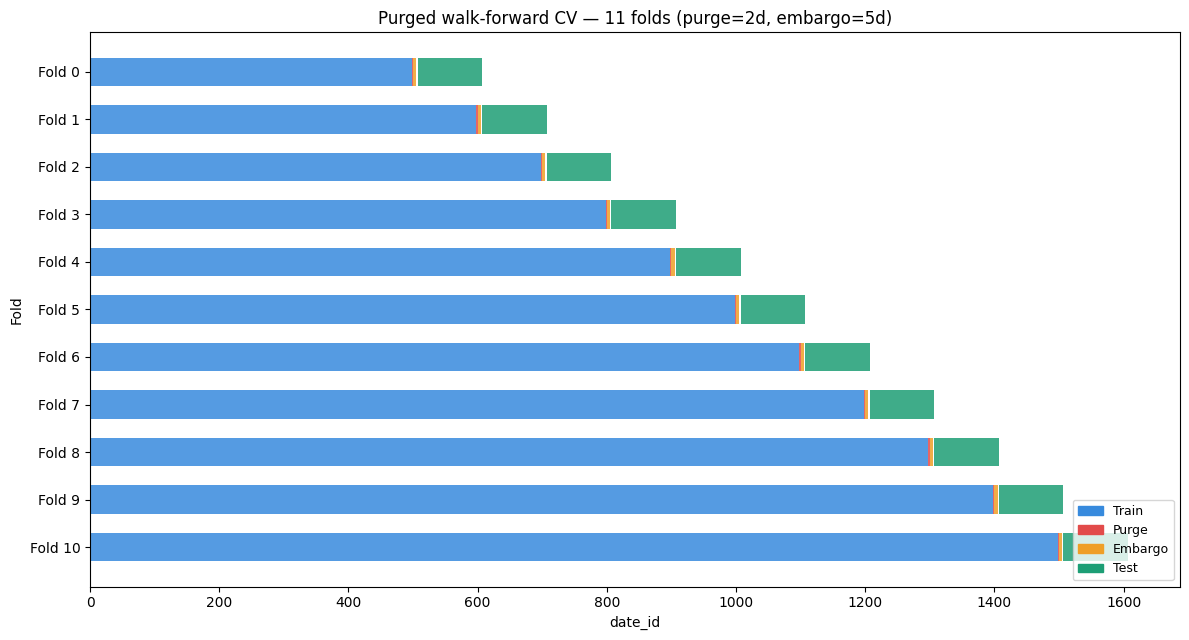

Gantt chart saved → results/cv/01_cv_gantt.png


In [46]:
# Gantt chart visualisation
 
print("=" * 70)
print("CV SPLIT GANTT CHART")
print("=" * 70)
 
fig, ax = plt.subplots(figsize=(12, max(3, cv.n_splits() * 0.5 + 1)))
 
colors = {
    "train":   "#378ADD",
    "purge":   "#E24B4A",
    "embargo": "#EF9F27",
    "test":    "#1D9E75",
}
 
date_min = all_dates[0]
date_max = all_dates[-1]
date_range = date_max - date_min
 
for fold in cv.get_splits():
    y = fold["fold"]
    for region, key in [("train_dates", "train"), ("purge_dates", "purge"),
                         ("embargo_dates", "embargo"), ("test_dates", "test")]:
        dates = fold[region]
        if len(dates) == 0:
            continue
        left  = dates[0]
        width = dates[-1] - dates[0] + 1
        ax.barh(y, width, left=left, height=0.6, color=colors[key],
                edgecolor="none", alpha=0.85)
 
ax.set_xlabel("date_id")
ax.set_ylabel("Fold")
ax.set_yticks(range(cv.n_splits()))
ax.set_yticklabels([f"Fold {i}" for i in range(cv.n_splits())])
ax.set_title(f"Purged walk-forward CV — {cv.n_splits()} folds "
             f"(purge={PURGE_GAP}d, embargo={EMBARGO_GAP}d)")
ax.invert_yaxis()
 
legend_patches = [mpatches.Patch(color=c, label=l.capitalize())
                  for l, c in colors.items()]
ax.legend(handles=legend_patches, loc="lower right", fontsize=9)
 
plt.tight_layout()
plt.savefig(RESULTS_DIR_D / "01_cv_gantt.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Gantt chart saved → {RESULTS_DIR_D / '01_cv_gantt.png'}")

In [47]:
# Unit tests
 
print("\n" + "=" * 70)
print("UNIT TESTS")
print("=" * 70)
 
n_passed = 0
n_tests  = 0
 
# Test 1: no test date appears in any train fold
n_tests += 1
overlap_found = False
for fold in cv.get_splits():
    train_set = set(fold["train_dates"])
    test_set  = set(fold["test_dates"])
    overlap   = train_set & test_set
    if len(overlap) > 0:
        overlap_found = True
        print(f"  FAIL: Fold {fold['fold']} has {len(overlap)} dates in both train and test")
        break
if not overlap_found:
    n_passed += 1
    print(f"  PASS: Test 1 — no test date appears in any train set")
 
# Test 2: purge gap is exactly purge_gap dates wide
n_tests += 1
purge_ok = True
for fold in cv.get_splits():
    if len(fold["purge_dates"]) != PURGE_GAP:
        purge_ok = False
        print(f"  FAIL: Fold {fold['fold']} purge has {len(fold['purge_dates'])} dates, expected {PURGE_GAP}")
        break
if purge_ok:
    n_passed += 1
    print(f"  PASS: Test 2 — purge gap is exactly {PURGE_GAP} dates in every fold")
 
# Test 3: embargo gap is exactly embargo_gap dates wide
n_tests += 1
embargo_ok = True
for fold in cv.get_splits():
    if len(fold["embargo_dates"]) != EMBARGO_GAP:
        embargo_ok = False
        print(f"  FAIL: Fold {fold['fold']} embargo has {len(fold['embargo_dates'])} dates, expected {EMBARGO_GAP}")
        break
if embargo_ok:
    n_passed += 1
    print(f"  PASS: Test 3 — embargo gap is exactly {EMBARGO_GAP} dates in every fold")
 
# Test 4: no purge or embargo date appears in train or test
n_tests += 1
gap_leak = False
for fold in cv.get_splits():
    train_set = set(fold["train_dates"])
    test_set  = set(fold["test_dates"])
    purge_set = set(fold["purge_dates"])
    emb_set   = set(fold["embargo_dates"])
    if (purge_set & train_set) or (purge_set & test_set):
        gap_leak = True
        print(f"  FAIL: Fold {fold['fold']} purge dates leak into train or test")
        break
    if (emb_set & train_set) or (emb_set & test_set):
        gap_leak = True
        print(f"  FAIL: Fold {fold['fold']} embargo dates leak into train or test")
        break
if not gap_leak:
    n_passed += 1
    print(f"  PASS: Test 4 — purge and embargo dates excluded from both train and test")
 
# Test 5: training window expands with each fold
n_tests += 1
expanding = True
prev_size = 0
for fold in cv.get_splits():
    curr_size = len(fold["train_dates"])
    if curr_size <= prev_size and fold["fold"] > 0:
        expanding = False
        print(f"  FAIL: Fold {fold['fold']} train size ({curr_size}) ≤ fold {fold['fold']-1} ({prev_size})")
        break
    prev_size = curr_size
if expanding:
    n_passed += 1
    print(f"  PASS: Test 5 — training window expands with each fold")
 
# Test 6: temporal ordering — all train dates < all test dates
n_tests += 1
temporal_ok = True
for fold in cv.get_splits():
    if fold["train_dates"][-1] >= fold["test_dates"][0]:
        temporal_ok = False
        print(f"  FAIL: Fold {fold['fold']} train max ({fold['train_dates'][-1]}) ≥ test min ({fold['test_dates'][0]})")
        break
if temporal_ok:
    n_passed += 1
    print(f"  PASS: Test 6 — all train dates strictly before all test dates")
 
print(f"\n  Results: {n_passed}/{n_tests} tests passed")
if n_passed == n_tests:
    print("  All tests passed ✓ — Purged Walk Forward CV implementation is correct")


UNIT TESTS
  PASS: Test 1 — no test date appears in any train set
  PASS: Test 2 — purge gap is exactly 2 dates in every fold
  PASS: Test 3 — embargo gap is exactly 5 dates in every fold
  PASS: Test 4 — purge and embargo dates excluded from both train and test
  PASS: Test 5 — training window expands with each fold
  PASS: Test 6 — all train dates strictly before all test dates

  Results: 6/6 tests passed
  All tests passed ✓ — Purged Walk Forward CV implementation is correct


In [48]:
# summary
 
print("\n" + "=" * 70)
print("COMPLETE SUMMARY")
print("=" * 70)
print(f"""
PurgedWalkForwardCV configured:
  Folds       : {cv.n_splits()}
  Purge gap   : {PURGE_GAP} dates
  Embargo gap : {EMBARGO_GAP} dates
  Test window : {TEST_WINDOW} dates
  Min train   : {MIN_TRAIN} dates
  Unit tests  : {n_passed}/{n_tests} passed
 
Files:
  {RESULTS_DIR_D / '01_cv_gantt.png'}
 
Usage:
  for train_mask, test_mask in cv.split_masks(df["date_id"].to_numpy()):
      X_train, y_train = X[train_mask], y[train_mask]
      X_test, y_test   = X[test_mask], y[test_mask]
""")


COMPLETE SUMMARY

PurgedWalkForwardCV configured:
  Folds       : 11
  Purge gap   : 2 dates
  Embargo gap : 5 dates
  Test window : 100 dates
  Min train   : 500 dates
  Unit tests  : 6/6 passed
 
Files:
  results/cv/01_cv_gantt.png
 
Usage:
  for train_mask, test_mask in cv.split_masks(df["date_id"].to_numpy()):
      X_train, y_train = X[train_mask], y[train_mask]
      X_test, y_test   = X[test_mask], y[test_mask]

